# Simple test to see how long data acquistion and offloading is taken:

In [ ]:
import sys
import time
import os
import random
import numpy as np
import scipy.ndimage as scp
import paramiko

from numpy.fft import fftshift

sys.path.append('./soft')
sys.path.append("/home/xilinx/jupyter_notebooks/bread_realOrig/Linux/libusb/example")

from top import *
from helpers import *
from sc5511a_lib import SC5511A

##########################################
# DIRECTORIES
##########################################

local_dir = "/home/xilinx/gaussian_experiments"
os.makedirs(local_dir, exist_ok=True)

remote_dir = "C:/Users/knirc/Desktop/gaussian_experiments"

##########################################
# SSH / SFTP SETUP
##########################################

hostname = "192.168.2.9"
username = "knirc"
key_path = "/home/xilinx/.ssh/id_rsa"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

print(f"Connecting to {hostname}...")
ssh.connect(hostname, username=username, key_filename=key_path)
sftp = ssh.open_sftp()

def ensure_remote_dir(sftp, remote_dir):
    remote_dir = remote_dir.replace("\\", "/")
    current = ""
    for part in remote_dir.split("/"):
        if not part:
            continue
        current += "/" + part
        try:
            sftp.mkdir(current)
        except IOError:
            pass

ensure_remote_dir(sftp, remote_dir)

##########################################
# USER CONFIG
##########################################

freq_center = 10000.0
settle_time = 0.002

##########################################
# Initialize Hardware
##########################################

soc = TopSoc('./bread_real.bit')
print(soc)

chain = DualChain(soc, soc['analysis'][0], soc['synthesis'][0])

##########################################
# Initialize LO
##########################################

TARGET_SERIAL = "10004A0F"

sig_gen = SC5511A()
devices = sig_gen.search_devices()

if TARGET_SERIAL not in devices:
    raise RuntimeError("LO not found")

sig_gen.open_device(TARGET_SERIAL)
sig_gen.set_rf_mode(0)
sig_gen.set_level(-10)
sig_gen.set_output(True)

##########################################
# Helper Functions
##########################################

def set_lo_freq(freq_mhz):
    sig_gen.set_freq(int(freq_mhz * 1e6))


def get_spectrum_raw(N_accum):
    x = chain.get_data_acc(N_accum)
    return fftshift(x)


def save_and_offload(filename, **data):

    local_path = f"{local_dir}/{filename}"
    remote_path = f"{remote_dir}/{filename}"

    np.savez(local_path, **data)

    sftp.put(local_path, remote_path)

    os.remove(local_path)


##########################################
# Measure spectrum size
##########################################

spec_len = len(get_spectrum_raw(10))
F = np.linspace(0, chain.fs, spec_len)
bins_per_MHz = spec_len / chain.fs

print("Spectrum bins:", spec_len)

##########################################
# PRE-MIX MASK SYSTEM
##########################################

flagged_bins = np.zeros(spec_len, dtype=bool)
bin_counts = np.zeros(spec_len)
bin_sums = np.zeros(spec_len)

flag_log = []

def premix_mask_update(Y, threshold=3.0):

    smooth = scp.gaussian_filter1d(Y, 20)
    enr = (Y - smooth) / (smooth + 1e-12)

    new_flags = np.where((enr > threshold) & (~flagged_bins))[0]

    for b in new_flags:
        flagged_bins[b] = True
        flag_log.append((time.time(), int(b)))

    return new_flags

##########################################
# OVERFLOW CHECK
##########################################

overflow_log = []

def check_overflow(Y):
    if np.any(Y < 0):
        overflow_log.append(time.time())
        return True
    return False

##########################################
# (A) TIMING BENCHMARK (MULTI-TRIAL)
##########################################

print("\n=== TEST A: Acquisition Timing ===")

timing_trials = []
timing_summary = []

TRIALS = 25   # number of repetitions per N

N_values = [10, 100, 1000, 10000, 25000, 50000, 75000, 100000]

for N in N_values:

    acquire_times = []
    offload_times = []

    print(f"\nTesting N={N} with {TRIALS} trials")

    for trial in range(TRIALS):

        t0 = time.time()
        Y = get_spectrum_raw(N)
        t1 = time.time()

        offload_start = time.time()
        Y2 = np.roll(Y, 0)
        offload_end = time.time()

        acquire = t1 - t0
        offload = offload_end - offload_start

        acquire_times.append(acquire)
        offload_times.append(offload)

        timing_trials.append({
            "N_accum": N,
            "trial": trial,
            "acquisition_time": acquire,
            "offload_time": offload
        })

    acquire_times = np.array(acquire_times)
    offload_times = np.array(offload_times)

    summary = {
        "N_accum": N,
        "acq_mean": np.mean(acquire_times),
        "acq_std": np.std(acquire_times),
        "acq_min": np.min(acquire_times),
        "acq_max": np.max(acquire_times),

        "off_mean": np.mean(offload_times),
        "off_std": np.std(offload_times),
        "off_min": np.min(offload_times),
        "off_max": np.max(offload_times)
    }

    timing_summary.append(summary)

    print(
        f"N={N} | "
        f"Acquire mean={summary['acq_mean']:.4f}s ±{summary['acq_std']:.4f} | "
        f"Offload mean={summary['off_mean']:.6f}s ±{summary['off_std']:.6f}"
    )

save_and_offload(
    "timing_test_multitrial.npz",
    timing_trials=timing_trials,
    timing_summary=timing_summary
)

##########################################
# (B) GAUSSIAN HOPPING EXPERIMENTS
##########################################

print("\n=== TEST B: Gaussian Hopping Variations ===")

def gaussian_hop(center, span):
    offset = random.gauss(0, span/3)
    offset = np.clip(offset, -span/2, span/2)
    freq = center + offset
    set_lo_freq(freq)
    return freq

def run_hop_experiment(span, hops_per_bin, hop_every, duration_sec=600):

    print(f"\nRunning span={span} MHz | hops/bin={hops_per_bin} | hop_every={hop_every}")

    start = time.time()

    lo_history = []
    spectrum_count = 0

    while time.time() - start < duration_sec:

        if spectrum_count % hop_every == 0:
            freq_now = gaussian_hop(freq_center, span)
        else:
            freq_now = freq_center

        time.sleep(settle_time)

        Y = get_spectrum_raw(10)

        lo_history.append(freq_now)

        check_overflow(Y)

        premix_mask_update(Y)

        valid = ~flagged_bins

        bin_sums[valid] += Y[valid]
        bin_counts[valid] += 1

        spectrum_count += 1

    min_count = int(np.min(bin_counts[~flagged_bins]))

    avg = np.zeros(spec_len)
    valid = (bin_counts >= min_count) & (~flagged_bins)
    avg[valid] = bin_sums[valid] / min_count

    filename = f"hop_span{span}_hop{hop_every}.npz"

    save_and_offload(
        filename,
        avg=avg,
        bin_counts=bin_counts,
        flagged_bins=flagged_bins,
        lo_history=np.array(lo_history),
        flag_log=np.array(flag_log, dtype=object),
        overflow_log=np.array(overflow_log)
    )

##########################################
# PARAMETER SWEEPS
##########################################

for span in [3, 10, 50, 200, 500, 750, 1000]:
    run_hop_experiment(span=span, hops_per_bin=1, hop_every=1)

for hop_every in [1, 5, 20, 100, 250]:
    run_hop_experiment(span=200, hops_per_bin=1, hop_every=hop_every)

##########################################
# CLEANUP
##########################################

sig_gen.set_output(False)
sig_gen.close_device()

sftp.close()
ssh.close()

print("\nAll tests complete.")

Connecting to 192.168.2.9...



BREAD configuration:

	Board: RFSoC4x2
	Analysis 0:
		ADC: 224_0, fs = 4915.2 MHz, Decimation    = 2
		PFB: fs = 307.2 MHz, fc = 153.6 MHz, 16 channels
Spectrum bins: 262144

=== TEST A: Acquisition Timing ===

Testing N=10 with 25 trials


# Basic 8-hour averaging with data-saving:

In [3]:
import sys, time, os
sys.path.append('./soft')
sys.path.append("/home/xilinx/jupyter_notebooks/bread_realOrig/Linux/libusb/example")

from top import *
from helpers import *

import numpy as np
from numpy.fft import fftshift
import paramiko

##########################################
### Initialize SoC and chain
##########################################
soc = TopSoc('./bread_real.bit')
print(soc)

chain = DualChain(soc, soc['analysis'][0], soc['synthesis'][0])

##########################################
### Parameters
##########################################
N_avg = 10000                 # hardware averaging
total_hours = 8
save_interval = 5 * 60        # 5 minutes
total_seconds = total_hours * 3600

##########################################
### Local storage
##########################################
local_dir = "/home/xilinx/linear_X_8hr_static"
os.makedirs(local_dir, exist_ok=True)

##########################################
### Remote destination
##########################################
remote_dir = "C:/Users/knirc/Desktop/linear_X_8hr_static"

##########################################
### SSH / SFTP setup
##########################################
hostname = "192.168.2.9"
username = "knirc"
key_path = "/home/xilinx/.ssh/id_rsa"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

print(f"Connecting to {hostname}...")
ssh.connect(hostname, username=username, key_filename=key_path)
sftp = ssh.open_sftp()
print("SFTP connected.")

def ensure_remote_dir(sftp, remote_dir):
    remote_dir = remote_dir.replace("\\", "/")
    current = ""
    for part in remote_dir.split("/"):
        if not part:
            continue
        current += "/" + part
        try:
            sftp.mkdir(current)
        except IOError:
            pass

ensure_remote_dir(sftp, remote_dir)
print("Remote directory verified.")

##########################################
### Spectrum helpers
##########################################
def get_inst_spectrum():
    return fftshift(chain.get_data_acc(1))

def get_avg_spectrum():
    return fftshift(chain.get_data_acc(N_avg))

##########################################
### Frequency axis (metadata)
##########################################
F = np.linspace(0, chain.fs, soc.FFT_N)

##########################################
### Acquisition loop
##########################################
print("\n=== Starting 8-hour static acquisition (LO untouched) ===")

start_time = time.time()
last_save = start_time
count = 0

# initialize placeholders (in case loop is very short)
inst = None
avg = None

while True:
    now = time.time()
    elapsed = now - start_time

    if elapsed >= total_seconds:
        break

    ##################################
    # Acquire spectra
    ##################################
    inst = get_inst_spectrum()
    avg  = get_avg_spectrum()

    count += 1

    ##################################
    # Periodic save
    ##################################
    if now - last_save >= save_interval:

        filename = f"t{int(elapsed):07d}s.npz"
        local_path  = f"{local_dir}/{filename}"
        remote_path = f"{remote_dir}/{filename}"

        np.savez(
            local_path,
            inst=inst,
            avg=avg,
            count=count,
            elapsed=elapsed,
            F=F
        )

        sftp.put(local_path, remote_path)
        os.remove(local_path)

        print(f"Saved @ {elapsed/3600:.2f} h | frames={count}")
        last_save = now

##########################################
### Final save
##########################################
filename = "FINAL.npz"
local_path  = f"{local_dir}/{filename}"
remote_path = f"{remote_dir}/{filename}"

np.savez(
    local_path,
    inst=inst,
    avg=avg,
    count=count,
    duration=elapsed,
    F=F
)

sftp.put(local_path, remote_path)
os.remove(local_path)

print(f"\nRun complete: {elapsed/3600:.1f} h, {count} frames")

##########################################
### Cleanup
##########################################
sftp.close()
ssh.close()

print("Connection closed. Done.")


BREAD configuration:

	Board: RFSoC4x2
	Analysis 0:
		ADC: 224_0, fs = 4915.2 MHz, Decimation    = 2
		PFB: fs = 307.2 MHz, fc = 153.6 MHz, 16 channels
Connecting to 192.168.2.9...
SFTP connected.
Remote directory verified.

=== Starting 8-hour static acquisition (LO untouched) ===
Saved @ 0.08 h | frames=148
Saved @ 0.17 h | frames=295
Saved @ 0.25 h | frames=442
Saved @ 0.33 h | frames=589
Saved @ 0.42 h | frames=736
Saved @ 0.50 h | frames=883
Saved @ 0.59 h | frames=1030
Saved @ 0.67 h | frames=1177
Saved @ 0.75 h | frames=1324
Saved @ 0.84 h | frames=1471
Saved @ 0.92 h | frames=1618
Saved @ 1.00 h | frames=1765
Saved @ 1.09 h | frames=1912
Saved @ 1.17 h | frames=2059
Saved @ 1.25 h | frames=2206
Saved @ 1.34 h | frames=2353
Saved @ 1.42 h | frames=2500
Saved @ 1.51 h | frames=2647
Saved @ 1.59 h | frames=2794
Saved @ 1.67 h | frames=2941
Saved @ 1.76 h | frames=3088
Saved @ 1.84 h | frames=3235
Saved @ 1.92 h | frames=3382
Saved @ 2.01 h | frames=3529
Saved @ 2.09 h | frames=36

# Pulls a snapshot of data to check spectrum looking normal prior to a long run:

Acquiring spectrum...


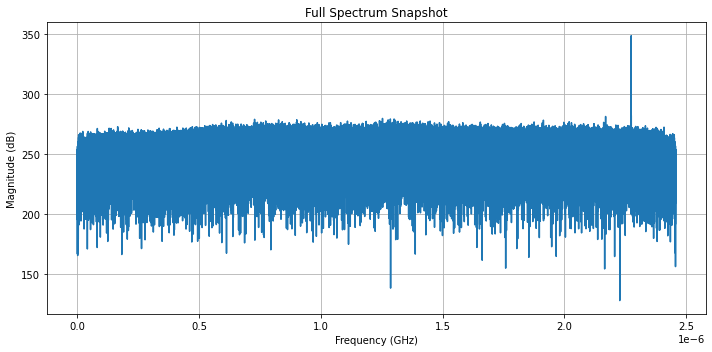

Done.


In [6]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftshift

##########################################
# Path setup
##########################################
sys.path.append('./soft')
sys.path.append("/home/xilinx/jupyter_notebooks/bread_realOrig/Linux/libusb/example")

##########################################
# Imports
##########################################
from top import *
from helpers import *

##########################################
# Init
##########################################
soc = TopSoc('./bread_real.bit')
chain = DualChain(soc, soc['analysis'][0], soc['synthesis'][0])

##########################################
# Acquire spectrum
##########################################
print("Acquiring spectrum...")
spec = fftshift(chain.get_data_acc(1))

##########################################
# IMPORTANT: match length of data
##########################################
F = np.linspace(0, chain.fs, len(spec))

##########################################
# Convert to dB
##########################################
spec_db = 20 * np.log10(np.abs(spec) + 1e-12)

##########################################
# Plot
##########################################
plt.figure(figsize=(10,5))
plt.plot(F/1e9, spec_db)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Magnitude (dB)")
plt.title("Full Spectrum Snapshot")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Done.")

# Saves both instaneous and cumulative spectra during runs:

Connecting to 192.168.2.9...
SFTP connected.
Acquiring initial snapshot...


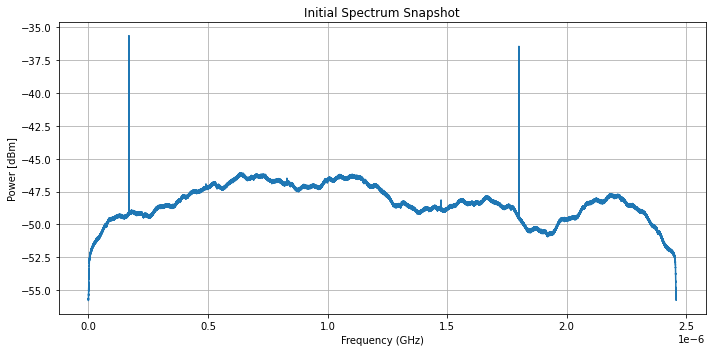

Starting 8-hour acquisition...
Frame 10, elapsed 0.3 min, avg_count=10
Frame 20, elapsed 0.6 min, avg_count=20
Frame 30, elapsed 0.9 min, avg_count=30
Frame 40, elapsed 1.2 min, avg_count=40
Frame 50, elapsed 1.5 min, avg_count=50
Frame 60, elapsed 1.8 min, avg_count=60
Frame 70, elapsed 2.1 min, avg_count=70
Frame 80, elapsed 2.4 min, avg_count=80
Frame 90, elapsed 2.7 min, avg_count=90
Frame 100, elapsed 3.1 min, avg_count=100
Frame 110, elapsed 3.4 min, avg_count=110
Frame 120, elapsed 3.7 min, avg_count=120
Frame 130, elapsed 4.0 min, avg_count=130
Frame 140, elapsed 4.3 min, avg_count=140
Frame 150, elapsed 4.6 min, avg_count=150
Frame 160, elapsed 4.9 min, avg_count=160
Saved 5-min cumulative data at t=0.08 h
Frame 170, elapsed 5.4 min, avg_count=7
Frame 180, elapsed 5.7 min, avg_count=17
Frame 190, elapsed 6.0 min, avg_count=27
Frame 200, elapsed 6.3 min, avg_count=37
Frame 210, elapsed 6.6 min, avg_count=47
Frame 220, elapsed 6.9 min, avg_count=57
Frame 230, elapsed 7.2 min, av

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftshift
import paramiko

sys.path.append('./soft')
sys.path.append("/home/xilinx/jupyter_notebooks/bread_realOrig/Linux/libusb/example")

from top import *
from helpers import *

# Initialize SoC and chain
soc = TopSoc('./bread_real.bit')
chain = DualChain(soc, soc['analysis'][0], soc['synthesis'][0])

# Parameters
N_avg = 10000           # hardware averaging per spectrum
R = 50                  # ohms
total_hours = 8
save_interval = 5*60    # 5 min
total_seconds = total_hours*3600

local_dir = "/home/xilinx/csv_8hr_run_fixed_dBm"
os.makedirs(local_dir, exist_ok=True)
remote_dir = "C:/Users/knirc/Desktop/csv_8hr_run_fixed_dBm"

# SSH / SFTP
hostname = "192.168.2.9"
username = "knirc"
key_path = "/home/xilinx/.ssh/id_rsa"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
print(f"Connecting to {hostname}...", flush=True)
ssh.connect(hostname, username=username, key_filename=key_path, timeout=10)
sftp = ssh.open_sftp()
print("SFTP connected.", flush=True)

def ensure_remote_dir(sftp, remote_dir):
    remote_dir = remote_dir.replace("\\","/")
    current = ""
    for part in remote_dir.split("/"):
        if not part:
            continue
        current += "/" + part
        try:
            sftp.mkdir(current)
        except IOError:
            pass
ensure_remote_dir(sftp, remote_dir)

# Initial snapshot for plotting
print("Acquiring initial snapshot...", flush=True)
spec_snapshot = fftshift(chain.get_data_acc(N_avg))
F = np.linspace(0, chain.fs, len(spec_snapshot))

# Proper dBm scaling (same as hop_comparison code)
spec_scaled = (spec_snapshot * (0.5 / 2**15)**2) / (soc.FFT_N**2)
spec_dbm = 10 * np.log10(spec_scaled / (2*R*1e-3) + 1e-12)

plt.figure(figsize=(10,5))
plt.plot(F/1e9, spec_dbm)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Power [dBm]")
plt.title("Initial Spectrum Snapshot")
plt.grid(True)
plt.tight_layout()
plt.show()

# Acquisition loop
print("Starting 8-hour acquisition...", flush=True)
start_time = time.time()
last_save = start_time
count = 0
avg_sum = None
avg_count = 0

while True:
    now = time.time()
    elapsed = now - start_time
    if elapsed >= total_seconds:
        break

    # Acquire spectra
    inst = fftshift(chain.get_data_acc(1))
    avg = fftshift(chain.get_data_acc(N_avg))
    count += 1

    # Initialize cumulative sum for 5-min window
    if avg_sum is None:
        avg_sum = np.zeros_like(avg)
        avg_count = 0
    avg_sum += avg
    avg_count += 1

    if count % 10 == 0:
        print(f"Frame {count}, elapsed {elapsed/60:.1f} min, avg_count={avg_count}", flush=True)

    # Save every 5 minutes
    if now - last_save >= save_interval:
        avg_cum = avg_sum / avg_count

        # Proper dBm conversion
        inst_scaled = (inst * (0.5 / 2**15)**2) / (soc.FFT_N**2)
        inst_dbm = 10 * np.log10(inst_scaled / (2*R*1e-3) + 1e-12)

        avg_scaled = (avg_cum * (0.5 / 2**15)**2) / (soc.FFT_N**2)
        avg_dbm = 10 * np.log10(avg_scaled / (2*R*1e-3) + 1e-12)

        filename = f"t{int(elapsed):07d}s.csv"
        local_path = os.path.join(local_dir, filename)
        remote_path = os.path.join(remote_dir, filename)

        # Save freq, inst_dbm, avg_dbm
        data = np.column_stack([F, inst_dbm, avg_dbm])
        header = "freq_Hz,inst_dBm,avg_dBm"
        np.savetxt(local_path, data, delimiter=",", header=header)

        sftp.put(local_path, remote_path)
        os.remove(local_path)
        print(f"Saved 5-min cumulative data at t={elapsed/3600:.2f} h", flush=True)

        # Reset accumulators
        avg_sum = None
        avg_count = 0
        last_save = now

# Final save
avg_cum = avg_sum / max(avg_count,1)
inst_scaled = (inst * (0.5 / 2**15)**2) / (soc.FFT_N**2)
inst_dbm = 10 * np.log10(inst_scaled / (2*R*1e-3) + 1e-12)
avg_scaled = (avg_cum * (0.5 / 2**15)**2) / (soc.FFT_N**2)
avg_dbm = 10 * np.log10(avg_scaled / (2*R*1e-3) + 1e-12)

filename = "FINAL.csv"
local_path = os.path.join(local_dir, filename)
remote_path = os.path.join(remote_dir, filename)
data = np.column_stack([F, inst_dbm, avg_dbm])
header = "freq_Hz,inst_dBm,avg_dBm"
np.savetxt(local_path, data, delimiter=",", header=header)
sftp.put(local_path, remote_path)
os.remove(local_path)
print(f"Final data saved after {elapsed/3600:.1f} h, total frames={count}", flush=True)

sftp.close()
ssh.close()
print("Connection closed. Done.", flush=True)

# Code for setting the LO frequency and turning it on by turning it to the right dBm:

In [ ]:
import sys
import time
import os
import random
import numpy as np
import scipy.ndimage as scp
from numpy.fft import fftshift

sys.path.append('./soft')
sys.path.append("/home/xilinx/jupyter_notebooks/bread_realOrig/Linux/libusb/example")

from top import *
from helpers import *
from sc5511a_lib import SC5511A

##########################################
# USER CONFIG
##########################################

TARGET_SERIAL = "10004A0F"
freq_mhz = 10000.0   # Set LO frequency here (MHz)
power_dbm = -10      # Output power

##########################################
# INITIALIZE SIGNAL GENERATOR
##########################################

sig_gen = SC5511A()
devices = sig_gen.search_devices()

print("Detected devices:", devices)

if TARGET_SERIAL not in devices:
    raise RuntimeError(f"SC5511A with serial {TARGET_SERIAL} not found")

sig_gen.open_device(TARGET_SERIAL)

##########################################
# CONFIGURE OUTPUT
##########################################

sig_gen.set_rf_mode(0)              # CW mode
sig_gen.set_level(power_dbm)        # Set power
sig_gen.set_freq(int(freq_mhz * 1e6))  # MHz -> Hz
sig_gen.set_output(True)

print(f"SC5511A set to {freq_mhz} MHz at {power_dbm} dBm")
print("RF output is ON")

##########################################
# KEEP IT ON?
##########################################

try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("\nTurning output OFF...")
    sig_gen.set_output(False)
    sig_gen.close_device()
    print("Done.")

Detected devices: ['10004A0F']
SC5511A set to 10000.0 MHz at -10 dBm
RF output is ON
